In [4]:
#All Imports here.
import cv2 as cv
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
from distutils.file_util import copy_file

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img
import os
import shutil
import random
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_curve, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import binary_accuracy
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB0, Xception
from tensorflow.keras.optimizers import Adam

**Data Loading**

In [5]:
# Define Dataset Paths
dataset_path = r"C:\Users\user\Desktop\DS Capstone Projects\Tuberculosis_Detection\Dataset of Tuberculosis Chest X-rays Images"
normal_path = os.path.join(dataset_path, "Normal Chest X-rays")
tb_path = os.path.join(dataset_path, "TB Chest X-rays")

print('Total Normal images:', len(os.listdir(normal_path)))
print('Total TB images:', len(os.listdir(tb_path)))

Total Normal images: 514
Total TB images: 2494


In [6]:
# To resize the images
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 10  # Increase for real training


In [7]:
new_base_dir = r"C:\Users\user\Desktop\DS Capstone Projects\Tuberculosis_Detection\basedir"

train_dir = os.path.join(new_base_dir, 'train')
val_dir = os.path.join(new_base_dir, 'validation')
test_dir = os.path.join(new_base_dir, 'test')

# Create subdirectories for TB and not TB in both train, test and validation folders
os.makedirs(os.path.join(train_dir, 'tb'), exist_ok=True)
os.makedirs(os.path.join(train_dir, 'normal'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'tb'), exist_ok=True)
os.makedirs(os.path.join(val_dir, 'normal'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'tb'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'normal'), exist_ok=True)

# Collect all image filenames for TB and not TB
tb_images = [os.path.join(tb_path, img) for img in os.listdir(tb_path) if img.endswith(('.png', '.jpg', '.jpeg'))]
normal_images = [os.path.join(normal_path, img) for img in os.listdir(normal_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

# Train-test-validation split (70% train,10% test, 20% validation)
tb_train, tb_temp = train_test_split(tb_images, test_size=0.3, random_state=42)
tb_val, tb_test = train_test_split(tb_temp, test_size=0.1, random_state=42)

normal_train, normal_temp = train_test_split(normal_images, test_size=0.3, random_state=42)
normal_val, normal_test = train_test_split(normal_temp, test_size=0.1, random_state=42)


# Function to copy images to a new directory
def move_images(image_list, destination_dir):
    for image_path in image_list:
        # #preprocess
        original_image = cv.imread(image_path)
        # processed_image = applyHE_CLAHE(original_image)

        filename = os.path.basename(image_path)
        processed_image_path = os.path.join(destination_dir, filename)
        cv.imwrite(processed_image_path, original_image)

#         shutil.copy(image_path, os.path.join(destination_dir, filename))

# Move TB images to train/test/validation directories
move_images(tb_train, os.path.join(train_dir, 'tb'))
move_images(tb_test, os.path.join(test_dir, 'tb'))
move_images(tb_val, os.path.join(val_dir, 'tb'))

# Move not TB images to train/test/validation directories
move_images(normal_train, os.path.join(train_dir, 'normal'))
move_images(normal_test, os.path.join(test_dir, 'normal'))
move_images(normal_val, os.path.join(val_dir, 'normal'))


print("Data successfully moved and split into train, test and validation sets.")

Data successfully moved and split into train, test and validation sets.


In [8]:
# check how many train images we have in each folder

print("Normal in training - ",len(os.listdir(os.path.join(train_dir, 'normal'))))
print("TB in training - ",len(os.listdir(os.path.join(train_dir, 'tb'))))
print("Normal in validation - ",len(os.listdir(os.path.join(val_dir, 'normal'))))
print("TB in validation - ",len(os.listdir(os.path.join(val_dir, 'tb'))))
print("Normal in test",len(os.listdir(os.path.join(test_dir, 'normal'))))
print("TB in test",len(os.listdir(os.path.join(test_dir, 'tb'))))

Normal in training -  359
TB in training -  1745
Normal in validation -  139
TB in validation -  674
Normal in test 16
TB in test 75


**Preprocessing, Data Augmentation and creating Data Loader**

In [9]:
#Pre-processing Here for CLAHE
def applyCLAHE(original_image):
    og_grey = cv.cvtColor(original_image, cv.COLOR_BGR2GRAY)
    if og_grey.dtype != np.uint8:
        og_grey = (og_grey * 255).astype(np.uint8)

    clahe=cv.createCLAHE(clipLimit=3)
    clahe_grey=clahe.apply(og_grey)

    # Convert to float32 and normalize to [0, 1]
    clahe_grey_float = clahe_grey.astype(np.float32) / 255.0
    clahe_grey_rgb = cv.merge([clahe_grey_float] * 3)


    return clahe_grey_rgb

In [10]:
def custom_augmentations(image):
    # Apply CLAHE
    clahe = cv.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    image = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
    image = clahe.apply(image)
    image = cv.cvtColor(image, cv.COLOR_GRAY2RGB)

    # Add Gaussian noise
    if np.random.rand() < 0.3:  # Fixed probability for Gaussian noise
        noise = np.random.normal(0, 10, image.shape).astype(np.uint8)  # Mean 0, std 10
        image = cv.add(image, noise)
    return image


def custom_validation_augmentations(image):
    # Apply CLAHE without adding noise
    clahe = cv.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    image = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)    
    image = clahe.apply(image)
    image = cv.cvtColor(image, cv.COLOR_GRAY2RGB)
    return image


# Define the data generators
train_datagen = ImageDataGenerator(
    horizontal_flip=0.5,  # Probability of horizontal flip
    rotation_range=5,  # Rotation range in degrees
    width_shift_range=0.05,  # Shift along x-axis
    height_shift_range=0.05,  # Shift along y-axis
    brightness_range=(1 - 0.1, 1 + 0.1),  # Brightness adjustment
    zoom_range=(1 - 0.05, 1 + 0.05),  # Scale factor for zooming
    preprocessing_function=custom_augmentations  # Custom augmentations
)

val_datagen = ImageDataGenerator(
    preprocessing_function=custom_validation_augmentations  # Apply CLAHE (no noise)
)


In [11]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMAGE_HEIGHT, IMAGE_WIDTH), batch_size=BATCH_SIZE, class_mode='binary')

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(IMAGE_HEIGHT, IMAGE_WIDTH), batch_size=BATCH_SIZE, class_mode='binary')



Found 2104 images belonging to 2 classes.
Found 813 images belonging to 2 classes.


In [12]:
from sklearn.utils import class_weight 
import numpy as np

# Create class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))


In [13]:
print("Class Indices:", train_gen.class_indices)

Class Indices: {'normal': 0, 'tb': 1}


**Exploratory Data Analysis (EDA)**

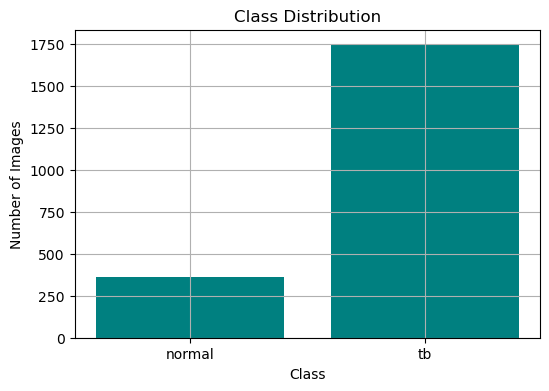

In [14]:
#  1. Class Distribution (Balance Check)

import os
import matplotlib.pyplot as plt

def plot_class_distribution(data_dir):
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))

    plt.figure(figsize=(6, 4))
    plt.bar(class_counts.keys(), class_counts.values(), color='teal')
    plt.title('Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.grid(True)
    plt.show()

plot_class_distribution(train_dir)



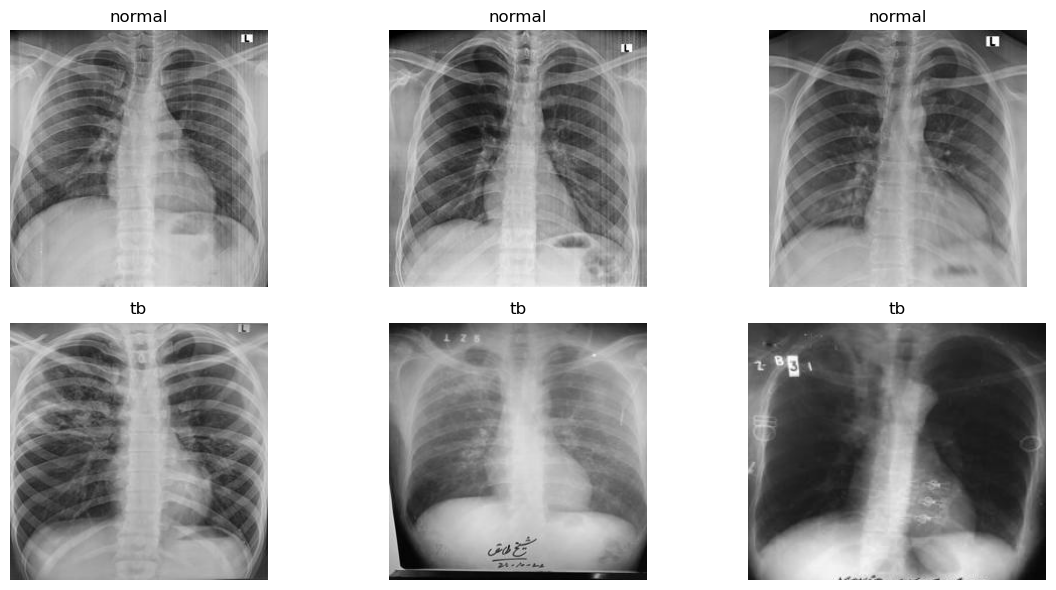

In [15]:
# 2. Sample Images per Class
import cv2
import numpy as np

def show_sample_images(data_dir, class_names, samples_per_class=3):
    plt.figure(figsize=(12, 6))
    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        images = os.listdir(class_path)[:samples_per_class]
        for i, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(len(class_names), samples_per_class, idx * samples_per_class + i + 1)
            plt.imshow(img)
            plt.title(f'{class_name}')
            plt.axis('off')
    plt.tight_layout()
    plt.show()

class_names = os.listdir(train_dir)
show_sample_images(train_dir, class_names)


In [16]:
# 3. Image Size & Shape Distribution

from collections import Counter

def image_shape_distribution(data_dir):
    shapes = []
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_path)[:200]:  # Sample 200 images
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                shapes.append(img.shape[:2])  # Height x Width

    shape_counts = Counter(shapes)
    print("Most common image sizes:", shape_counts.most_common(5))

image_shape_distribution(train_dir)


Most common image sizes: [((256, 256), 394), ((215, 256), 2), ((221, 256), 1), ((224, 234), 1), ((214, 256), 1)]


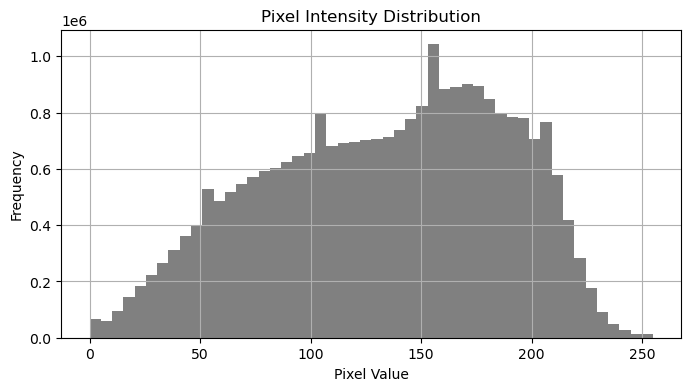

In [17]:
# 4. Pixel Intensity Statistics

def pixel_intensity_analysis(data_dir, class_names):
    all_pixels = []
    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_path)[:200]:  # Sample 200 images
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                all_pixels.extend(img.flatten())

    all_pixels = np.array(all_pixels)
    plt.figure(figsize=(8, 4))
    plt.hist(all_pixels, bins=50, color='gray')
    plt.title('Pixel Intensity Distribution')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

pixel_intensity_analysis(train_dir, class_names)


**Model Building**

In [18]:
# Function to Build Model

def build_model(base_model, name):
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=output, name=name)
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [19]:
# Create All Three Models

resnet_model = build_model(ResNet50(include_top=False, weights='imagenet', input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)), "ResNet50")
vgg_model = build_model(VGG16(include_top=False, weights='imagenet', input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)), "VGG16")
efficientnet_model = build_model(EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)), "EfficientNetB0")


In [20]:
# Train and Evaluate Function

def train_and_evaluate(model, train_gen, val_gen):
    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS,  class_weight=class_weights)
    val_loss, val_acc = model.evaluate(val_gen)
    
    print(f"\nModel: {model.name}\nValidation Accuracy: {val_acc:.4f}\n")
    return history


**Model Training**

In [21]:
# Train All Models
histories = {}

for model in [resnet_model, vgg_model, efficientnet_model]:
    print(f"\nTraining {model.name}...\n")
    histories[model.name] = train_and_evaluate(model, train_gen, val_gen)



Training ResNet50...



C:\Users\user\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.5071 - loss: 0.8089 - val_accuracy: 0.8290 - val_loss: 0.6326
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.5265 - loss: 0.7228 - val_accuracy: 0.8290 - val_loss: 0.5988
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.5951 - loss: 0.6840 - val_accuracy: 0.1784 - val_loss: 0.7732
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.5019 - loss: 0.6911 - val_accuracy: 0.8401 - val_loss: 0.6273
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.5377 - loss: 0.6948 - val_accuracy: 0.8303 - val_loss: 0.6167
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.5694 - loss: 0.6864 - val_accuracy: 0.7811 - val_loss: 0.6759
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.4765 - loss: 0.6884 - val_accuracy: 0.8290 - val_loss: 0.5998
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.6240 - loss: 0.6697 - val_accuracy: 0.8290 - v

**Experimentation & Evaluation** 


In [22]:
# Data Augmentation

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='binary')
val_generator = val_test_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='binary')
test_generator = val_test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)


Found 2104 images belonging to 2 classes.
Found 813 images belonging to 2 classes.
Found 91 images belonging to 2 classes.


In [23]:
# Class Weighting Helps handle class imbalance.
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Computed Class Weights:", class_weights)


Computed Class Weights: {0: 2.9303621169916436, 1: 0.602865329512894}


In [24]:
# Function to Build Transfer Learning Models

# Function to Build Transfer Learning Models (Updated for Fine-Tuning)
def build_model(base_model, model_name="EfficientNetB0", input_shape=(224, 224, 3), dropout_rate=0.5, dense_units=128):
    # Unfreeze top layers of base model for fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate / 2)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    print(f"{model_name} model built and compiled.")
    return model


In [ ]:
# Train All Models in a Loop
from tensorflow.keras.callbacks import EarlyStopping

base_models = {
    "VGG16": VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3)),
    "ResNet50": ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3)),
    "EfficientNetB0": EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

trained_models = {}

for name, base_model in base_models.items():
    print(f"\n🔄 Starting training for: {name}")
    model = build_model(base_model, model_name=name)
    
    history = model.fit(
        train_generator,
        epochs=15,
        validation_data=val_generator,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1  # ensure output is shown per epoch
    )
    
    print(f"✅ Finished training {name}. Saving model...\n")
    model.save(f"saved_models/{name}_tb_model.keras")
    trained_models[name] = model




🔄 Starting training for: VGG16
VGG16 model built and compiled.


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
57/66 ━━━━━━━━━━━━━━━━━━━━ 19:29 130s/step - accuracy: 0.5749 - loss: 0.6399

In [ ]:
# EfficientNetB0 Debugging

# Set image size for EfficientNetB0
img_size = 224
batch_size = 32


# Load base model with correct input size
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3))

# Build model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Unfreeze base model for fine-tuning
base_model.trainable = True

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.2)
checkpoint = ModelCheckpoint('efficientnetb0_best_model.keras', monitor='val_loss', save_best_only=True)

# 7. Fit the model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


In [ ]:
# Evaluation Function for All Models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, roc_curve
def evaluate_model(model, model_name, test_generator):
    y_true = test_generator.classes
    y_pred_prob = model.predict(test_generator)
    y_pred = (y_pred_prob > 0.5).astype("int32")

    # Flatten predictions if needed
    if y_pred.shape[-1] == 1:
        y_pred = y_pred.flatten()
    
    print(f"\n===== Evaluation for {model_name} =====")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # ROC-AUC
    roc_auc = roc_auc_score(y_true, y_pred_prob)
    print("\nROC-AUC Score:", roc_auc)

    # F1 Score
    f1 = f1_score(y_true, y_pred)
    
    # Accuracy, Precision, Recall
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)

    # ROC Curve Plot
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()

    precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)

    # Return metrics
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }, fpr, tpr, precision, recall

metrics, fpr, tpr, precision_vals, recall_vals = evaluate_model(model, "VGG16", test_generator)
print(metrics)

In [ ]:
# Loop through models and collect results
results = []
roc_curves = {}
pr_curves = {}

for name, model in trained_models.items():
    metrics, fpr, tpr, precision, recall = evaluate_model(model, name, test_generator)
    results.append(metrics)
    roc_curves[name] = (fpr, tpr, metrics["ROC-AUC"])
    pr_curves[name] = (precision, recall)


In [ ]:
# Plot all ROC curves together
plt.figure(figsize=(8, 6))

for model_name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
plt.figure(figsize=(8, 6))

for model_name, (precision, recall) in pr_curves.items():
    plt.plot(recall, precision, label=f"{model_name}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


In [ ]:
# Display all results in a table

results_df = pd.DataFrame(results)
print("\n Model Evaluation Summary:")
print(results_df.sort_values(by="F1 Score", ascending=False))

**Saving VGG16 Model for Deployment**

In [ ]:
# Save EfficientNetB0
best_model = trained_models["VGG16"]
# Save using the recommended Keras format
best_model.save("saved_models/VGG16_tb_model.keras")
print("Model saved to saved_models/VGG16_tb_model.keras")


In [ ]:
best_model.save("saved_models/VGG16_tb_model.h5")